In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import mnist
import matplotlib.pyplot as plt


(x_train , y_train), (x_test,y_test) = mnist.load_data()

x_train=x_train.astype("float32")/255.0
x_test=x_test.astype("float32")/255.0
print(x_train.shape)




(60000, 28, 28)


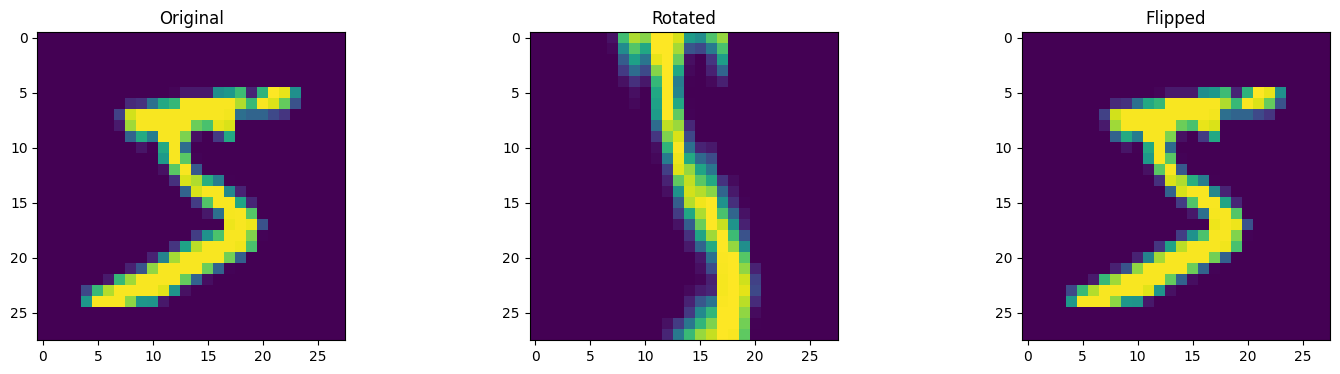

In [ ]:
#diplay original and augmented images
import numpy as np
image = x_train[0]

rotation = layers.RandomRotation(0.2)
flip = layers.RandomFlip("horizontal_and_vertical")


aug_rotation = rotation(image[np.newaxis, :])[0].numpy()
aug_flip = flip(image[np.newaxis, :])[0].numpy()

plt.figure(figsize=(18,4))
plt.subplot(1,3,1)
plt.imshow(image,label="original")
plt.title("Original")

plt.subplot(1,3,2)
plt.imshow(aug_rotation,label="rotated")
plt.title("Rotated")

plt.subplot(1,3,3)
plt.imshow(aug_flip,label="flipped")
plt.title("Flipped")

plt.show()

In [ ]:
#transforming dimension from 3 to 4 in order for the model to work
import numpy as np

x_train = np.expand_dims(x_train,axis=-1)
x_test = np.expand_dims(x_test,axis=-1)

In [ ]:
#cnn with dropout


data_augmentation = models.Sequential([
    layers.RandomRotation(0.2),
    layers.RandomFlip("horizontal_and_vertical")
])


cnn_model_aug = models.Sequential([
    data_augmentation,
    layers.Conv2D(32,(3,3),activation="relu",input_shape=(28,28)),
    layers.MaxPool2D((2,2)),
    layers.Conv2D(64,(3,3),activation="relu"),
    layers.MaxPool2D((2,2)),
    layers.Conv2D(128,(3,3),activation="relu"),
    layers.Flatten(),
    layers.Dense(256,activation="relu"),
    layers.Dropout(0.25),
    layers.Dense(128,activation="relu"),
    layers.Dropout(0.1),
    layers.Dense(10,activation="softmax")

])


cnn_model_aug.compile(
    optimizer=tf.keras.optimizers.Adam(),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"]
)


model = cnn_model_aug.fit(
    x=x_train,
    y=y_train,
    epochs=10,
    batch_size=64,
    validation_data = (x_test,y_test)
)



/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - accuracy: 0.8169 - loss: 0.5479 - val_accuracy: 0.9527 - val_loss: 0.1555
Epoch 2/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.9348 - loss: 0.2092 - val_accuracy: 0.9586 - val_loss: 0.1257
Epoch 3/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - accuracy: 0.9488 - loss: 0.1648 - val_accuracy: 0.9636 - val_loss: 0.1095
Epoch 4/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.9562 - loss: 0.1420 - val_accuracy: 0.9710 - val_loss: 0.0913
Epoch 5/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - accuracy: 0.9604 - loss: 0.1301 - val_accuracy: 0.9725 - val_loss: 0.0903
Epoch 6/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.9627 - loss: 0.1204 - val_accuracy: 0.9769 - val_loss: 0.0717
Epoch 7/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - accuracy: 0.9664 - loss: 0.1124 - val_accuracy: 0.9782 - val_loss: 0.0653
Epoch 8/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - accuracy: 0.9677 - loss: 0.1047 - val_accurac

i chose the data augmentation techniques of flipping and rotating to make sure there is more diversity when it comes to how the image is provided to the model. this leads to better generalization and greater variety in data for learning.




the impact of drop out is significantly crucial for reducing overfitting and forcing the neurons to learn without depending on another neuron. this leads to higher training and validation accuracy and a decrease in their losses.